In [2]:
"""
GRU Flood Forecasting Model
Predicts streamflow 24 hours ahead using the top30 high flood-severity sites.
"""
import torch
import numpy as np
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping

from src.preprocessing.preprocessing import processor
from src.models.gru import GRUModel
from src.utils.helpers import create_sequences

STATIC_FEATURES = [
    "longitude", "latitude", "DRAIN_SQKM", "artificial_path_pct",
    "wb5100_ann_mm", "snw_pc_syr", "snow_ice_nlcd06", "barren_nlcd06",
    "mains100_plant", "hga", "hgc", "bulk_density_avg", "elev_max_m", "aspect_deg"
]

DYNAMIC_FEATURES = [
    "streamflow_cfs_mean", "streamflow_cfs_max", "streamflow_cfs_min",
    "gage_height_ft_mean",
    "precipitation_mm",
    "temperature_c",
    "potential_evaporation_mm",
    "specific_humidity_kgkg",
    "shortwave_radiation_wm2",
    "longwave_radiation_wm2",
    "wind_speed_ms",
    "surface_pressure_pa",
    "cape_jkg",
    "convective_precip_fraction",
]

TARGET = "streamflow_cfs_mean" 

WINDOW_SIZE = 72

config = {
    "input_cols": DYNAMIC_FEATURES + STATIC_FEATURES,
    "static_cols": STATIC_FEATURES,
    "target": "streamflow_cfs_target_24h",
    "train_split": 0.8,
    "val_split": 0.9,
    "file_path": "flood-dataset-top30",
    "file_name": "flood_model_top30",
    "table": "wandb.flood_model_top30",
    "lag_window": 1,
    "frequency": "hourly",
    "split_time_days": 30,
    "site_scaling": False,
}

In [3]:
pcr = processor.load(name="default_preprocessor")
pcr.pull_wandb()
print(pcr.df["site_id"].unique())
print(pcr.df.shape)
train_X, val_X, test_X, train_y, val_y, test_y = pcr.return_outputs()

wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from C:\Users\sacha\_netrc.
wandb: Downloading large artifact 'flood-dataset-top30:latest', 137.80MB. 1 files...
wandb:   1 of 1 files downloaded.  
Done. 00:00:00.7 (210.1MB/s)


Starting preprocessing: 4,639,150 rows, 31 columns
After lag null removal: 3,342,204 rows, 28 features
Splitting by time...
Train: 2,673,814 | Val: 334,132 | Test: 334,258
Scaling features and targets...
Scaling complete.
shape: (37,)
Series: 'site_id' [str]
[
	"06894200"
	"06911000"
	"06347000"
	"06452320"
	"06915000"
	…
	"06401500"
	"06463500"
	"06332515"
	"06869500"
	"06870300"
]
(4639150, 31)


In [4]:
print("Creating sequences...")
X_train, y_train, train_site_ids = create_sequences(train_X, train_y, WINDOW_SIZE)
X_val, y_val, val_site_ids = create_sequences(val_X, val_y, WINDOW_SIZE)
X_test, y_test, test_site_ids = create_sequences(test_X, test_y, WINDOW_SIZE)
print("Sequences created.")

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")


Creating sequences...
Sequences created.
Train: (2671222, 72, 28), Val: (331540, 72, 28), Test: (331666, 72, 28)


In [5]:
gru = GRUModel(
    gru_units=(32, 16),
    dense_units=64,
    dropout_rate=0.3,
    under_predict_penalty=1,
    learning_rate=1e-3,
)

gru.build(input_shape=(WINDOW_SIZE, X_train.shape[2]))
gru.summary()

# %%
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
)

gru.fit(
    (X_train, y_train),
    val_ds=(X_val, y_val),
    epochs=50,
    callbacks=[early_stopping],
    batch_size=32,
)

c:\Users\sacha\RiceLocal\Capstone\Coding\Flood-Forecasting\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 72, 32)         │         5,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 72, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 16)             │         2,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,505 (37.13 KB)

 Trainable params: 9,505 (37.13 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
83476/83476 ━━━━━━━━━━━━━━━━━━━━ 1028s 12ms/step - loss: 0.2419 - mae: 0.1536 - val_loss: 0.2612 - val_mae: 0.1489
Epoch 2/50
83476/83476 ━━━━━━━━━━━━━━━━━━━━ 1022s 12ms/step - loss: 0.2298 - mae: 0.1451 - val_loss: 0.2805 - val_mae: 0.1545
Epoch 3/50
83476/83476 ━━━━━━━━━━━━━━━━━━━━ 1016s 12ms/step - loss: 0.2431 - mae: 0.1481 - val_loss: 0.2863 - val_mae: 0.1398
Epoch 4/50
83476/83476 ━━━━━━━━━━━━━━━━━━━━ 1016s 12ms/step - loss: 0.2407 - mae: 0.1460 - val_loss: 0.2850 - val_mae: 0.1509
Epoch 5/50
83476/83476 ━━━━━━━━━━━━━━━━━━━━ 1010s 12ms/step - loss: 0.2630 - mae: 0.1554 - val_loss: 0.3412 - val_mae: 0.1647
Epoch 6/50
83476/83476 ━━━━━━━━━━━━━━━━━━━━ 1025s 12ms/step - loss: 0.2768 - mae: 0.1636 - val_loss: 0.3348 - val_mae: 0.1545


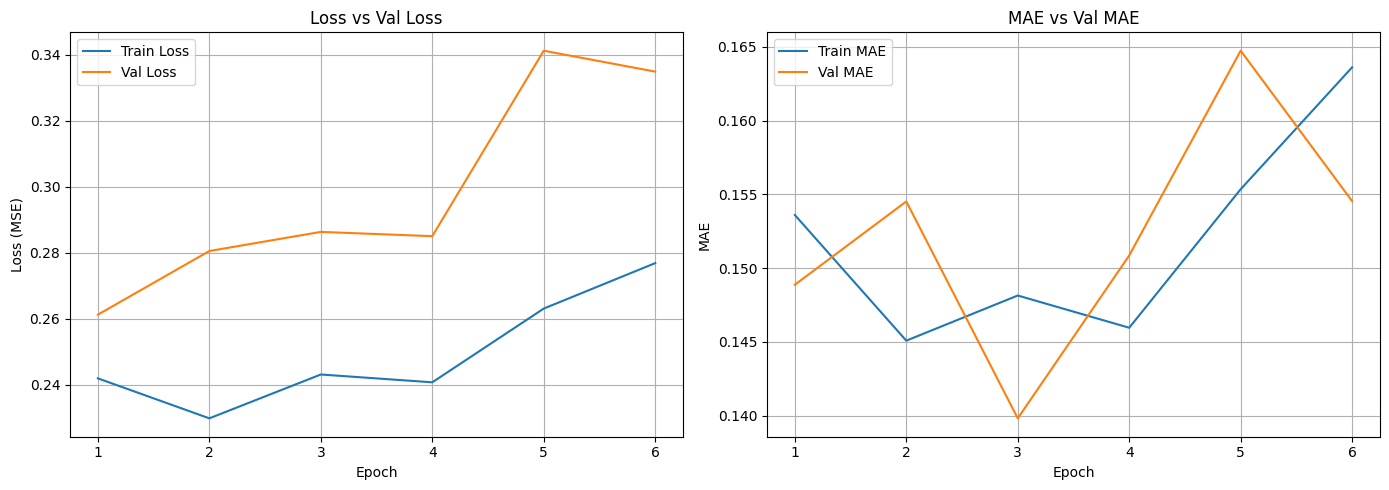

In [6]:
gru.plot_training_history()

In [7]:
gru.save_model(name="gru_model")

WindowsPath('C:/Users/sacha/RiceLocal/Capstone/Coding/Flood-Forecasting/models/gru_model.keras')